In [1]:
import os
import numpy as np
import pandas as pd
import shutil
import cv2
import math
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2


I0000 00:00:1781863650.520050   91163 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781863650.574074   91163 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781863652.078244   91163 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
anti_spoofing_path = "/home/akash/.cache/kagglehub/datasets/tapakah68/anti-spoofing/versions/3"
anti_spoofing_live_dataset_path = "/home/akash/.cache/kagglehub/datasets/axondata/anti-spoofing-live-dataset/versions/1"
real_vs_fake_anti_spoofing_video_classification_path = "/home/akash/.cache/kagglehub/datasets/trainingdatapro/real-vs-fake-anti-spoofing-video-classification/versions/1"

In [14]:
import shutil

# Define where the folder is now
source_folder = real_vs_fake_anti_spoofing_video_classification_path

# Define where you want to move it
destination_folder = "/home/akash/my_project/downloads/real_vs_fake_anti_spoofing_video_classification/"

# Move the entire directory
shutil.move(source_folder, destination_folder)
print("Folder moved successfully!")

Folder moved successfully!


In [15]:
shutil.rmtree('/home/akash/my_project/downloads/anti_spoofing/cut-out printouts')
print("Folder Deleted successfully!")

Folder Deleted successfully!


In [8]:
import os
import cv2
import glob
import albumentations as A

# 1. Define paths
input_folder = "downloads/local_data/live"  # Put your multiple real photos here
output_folder = "downloads/local_data/live"          # Augmented images will save here
os.makedirs(output_folder, exist_ok=True)

# 2. Get list of all real images (.jpg, .jpeg, or .png)
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob(os.path.join(input_folder, ext)))

if not image_paths:
    print(f"Error: No images found in {input_folder}")
    exit()

# 3. SAFELY UPDATED FOR ANTI-SPOOFING (Removed Noise, Blur, and High Limits)
transform_pool = [
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.12, contrast_limit=0.12, p=1.0),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=5, p=1.0),
    A.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, p=1.0),
    A.Compose([A.HorizontalFlip(p=1.0), A.RandomBrightnessContrast(brightness_limit=0.1, p=1.0)]),
    A.Compose([A.ShiftScaleRotate(scale_limit=0.03, rotate_limit=3, p=1.0), A.ColorJitter(saturation=0.03, p=1.0)])
]

# 4. Generate exactly 10 total images loop
target_total = 13*6
generated_count = 0

print(f"Processing {len(image_paths)} original images to create {target_total} total variations...")

while generated_count < target_total:
    for img_path in image_paths:
        if generated_count >= target_total:
            break
            
        # Load image
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Pick an augmentation style based on current count
        aug_index = generated_count % len(transform_pool)
        transform = transform_pool[aug_index]
        
        # Apply transformation
        augmented = transform(image=image)
        augmented_image = augmented['image']
        
        # Save output
        save_image = cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR)
        output_path = os.path.join(output_folder, f"real_multi_aug_{generated_count+1}.jpg")
        cv2.imwrite(output_path, save_image)
        
        generated_count += 1

print(f"Done! Created {generated_count} balanced images in {output_folder}")


Processing 11 original images to create 78 total variations...
Done! Created 78 balanced images in downloads/local_data/live


In [15]:
import os
import cv2
import math
from tqdm import tqdm

# --- Configuration & Hyperparameters ---
# Change this to the path where your 'train' and 'val' folders currently live
INPUT_BASE_DIR = '/home/akash/my_project/downloads' 
OUTPUT_BASE_DIR = '/home/akash/my_project/new_processed_dataset'
IMG_SIZE = 224
SCALE_FACTOR = 1.5
VIDEO_STRIDE = 10  # Process 1 frame every 10 frames

# Load the face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def process_and_save_wide_face(frame, save_path, scale_factor=1.5):
    """
    Detects the largest face, crops a 1.5x wide bounding box around it 
    for MobileNetV2, and saves it.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces) > 0:
        # Select the largest face detected
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

        # Calculate centers
        cx, cy = x + w // 2, y + h // 2

        # Expand width and height dynamically by scale_factor (1.5x)
        new_w = int(w * scale_factor)
        new_h = int(h * scale_factor)

        # Calculate new top-left coordinates ensuring boundaries
        img_h, img_w, _ = frame.shape
        new_x = max(0, cx - new_w // 2)
        new_y = max(0, cy - new_h // 2)

        # Ensure bottom-right coordinates stay within boundaries
        end_x = min(img_w, new_x + new_w)
        end_y = min(img_h, new_y + new_h)

        # Crop the wider region
        face_crop = frame[new_y:end_y, new_x:end_x]

        # Resize safely to MobileNetV2 exact target size
        if face_crop.size > 0:
            resized = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))
            cv2.imwrite(save_path, resized)
            return True

    return False

# --- Dataset Traversal and Processing ---
splits = ['train', 'val']

for split in splits:
    current_split_dir = os.path.join(INPUT_BASE_DIR, split)
    
    if not os.path.exists(current_split_dir):
        print(f"Skipping missing split directory: {current_split_dir}")
        continue
        
    # Scan the subdirectories inside train/val to handle case-insensitivity dynamically
    raw_subfolders = os.listdir(current_split_dir)
    
    for folder_name in raw_subfolders:
        # Hidden files check
        if folder_name.startswith('.'):
            continue
            
        lower_folder = folder_name.lower()
        # Ensure we only process 'live' or 'attack' folders
        if lower_folder not in ['live', 'attack']:
            continue
            
        # Target folder mapping (force lowercase output)
        target_class = lower_folder
        source_class_dir = os.path.join(current_split_dir, folder_name)
        
        # Create corresponding output folder in new_processed_dataset
        target_output_dir = os.path.join(OUTPUT_BASE_DIR, split, target_class)
        os.makedirs(target_output_dir, exist_ok=True)
        
        # Gather all mixed media files in this folder
        all_files = sorted([f for f in os.listdir(source_class_dir) if not f.startswith('.')])
        
        print(f"\n📂 Processing: {split}/{folder_name} —> Saving to: {split}/{target_class}")
        
        for filename in tqdm(all_files, desc=f"Processing {split}_{target_class}", unit="file"):
            file_path = os.path.join(source_class_dir, filename)
            
            # 1. Handle Static Image Processing
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                img = cv2.imread(file_path)
                if img is not None:
                    # Clean filename to avoid extension confusion
                    base_name = os.path.splitext(filename)[0]
                    save_name = f"img_{base_name}.jpg"
                    process_and_save_wide_face(img, os.path.join(target_output_dir, save_name), SCALE_FACTOR)

            # 2. Handle Video Sequences (Sampling 1 frame every 10 frames)
            elif filename.lower().endswith(('.mp4', '.avi', '.mov', '.mkv', '.wmv')):
                cap = cv2.VideoCapture(file_path)
                frame_count = 0

                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break

                    # Stride filter: process only every 10th frame
                    if frame_count % VIDEO_STRIDE == 0:
                        base_name = os.path.splitext(filename)[0]
                        save_name = f"vid_{base_name}_f{frame_count}.jpg"
                        process_and_save_wide_face(frame, os.path.join(target_output_dir, save_name), SCALE_FACTOR)
                    frame_count += 1

                cap.release()

print("\n🚀 All images and video frames successfully processed, 1.5x cropped, and saved to lowercased destinations!")



📂 Processing: train/Attack —> Saving to: train/attack


Processing train_attack: 100%|██████████| 86/86 [04:10<00:00,  2.92s/file]



📂 Processing: train/live —> Saving to: train/live


Processing train_live: 100%|██████████| 194/194 [03:57<00:00,  1.22s/file]



📂 Processing: val/attack —> Saving to: val/attack


Processing val_attack: 100%|██████████| 28/28 [01:31<00:00,  3.28s/file]



📂 Processing: val/live —> Saving to: val/live


Processing val_live: 100%|██████████| 108/108 [01:54<00:00,  1.06s/file]


🚀 All images and video frames successfully processed, 1.5x cropped, and saved to lowercased destinations!


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/home/akash/my_project/new_processed_dataset/train",
    image_size = (224, 224),
    batch_size = 32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/home/akash/my_project/new_processed_dataset/val",
    image_size = (224, 224),
    batch_size = 32
)

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     "/home/akash/my_project/processed_dataset/test",
#     image_size = (224, 224),
#     batch_size = 32
# )

Found 4448 files belonging to 2 classes.


I0000 00:00:1781863659.098036   91163 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1463 files belonging to 2 classes.


['/home/akash/my_project/new_processed_dataset/train/attack/vid_VID20260618201404_f120.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_18_f240.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_WIN_20260618_20_18_06_Pro_f930.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_26_f180.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_2_f210.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_30_f590.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_0001ffba3c--6289196875a5cf63cd0cb302__Samsung galaxy s20 __IPhone 6s plus_f140.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_23_f60.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_WIN_20260618_20_20_07_Pro_f870.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_3_f250.jpg', '/home/akash/my_project/new_processed_dataset/train/attack/vid_46_f10.jpg', '/home/akash/my_project/

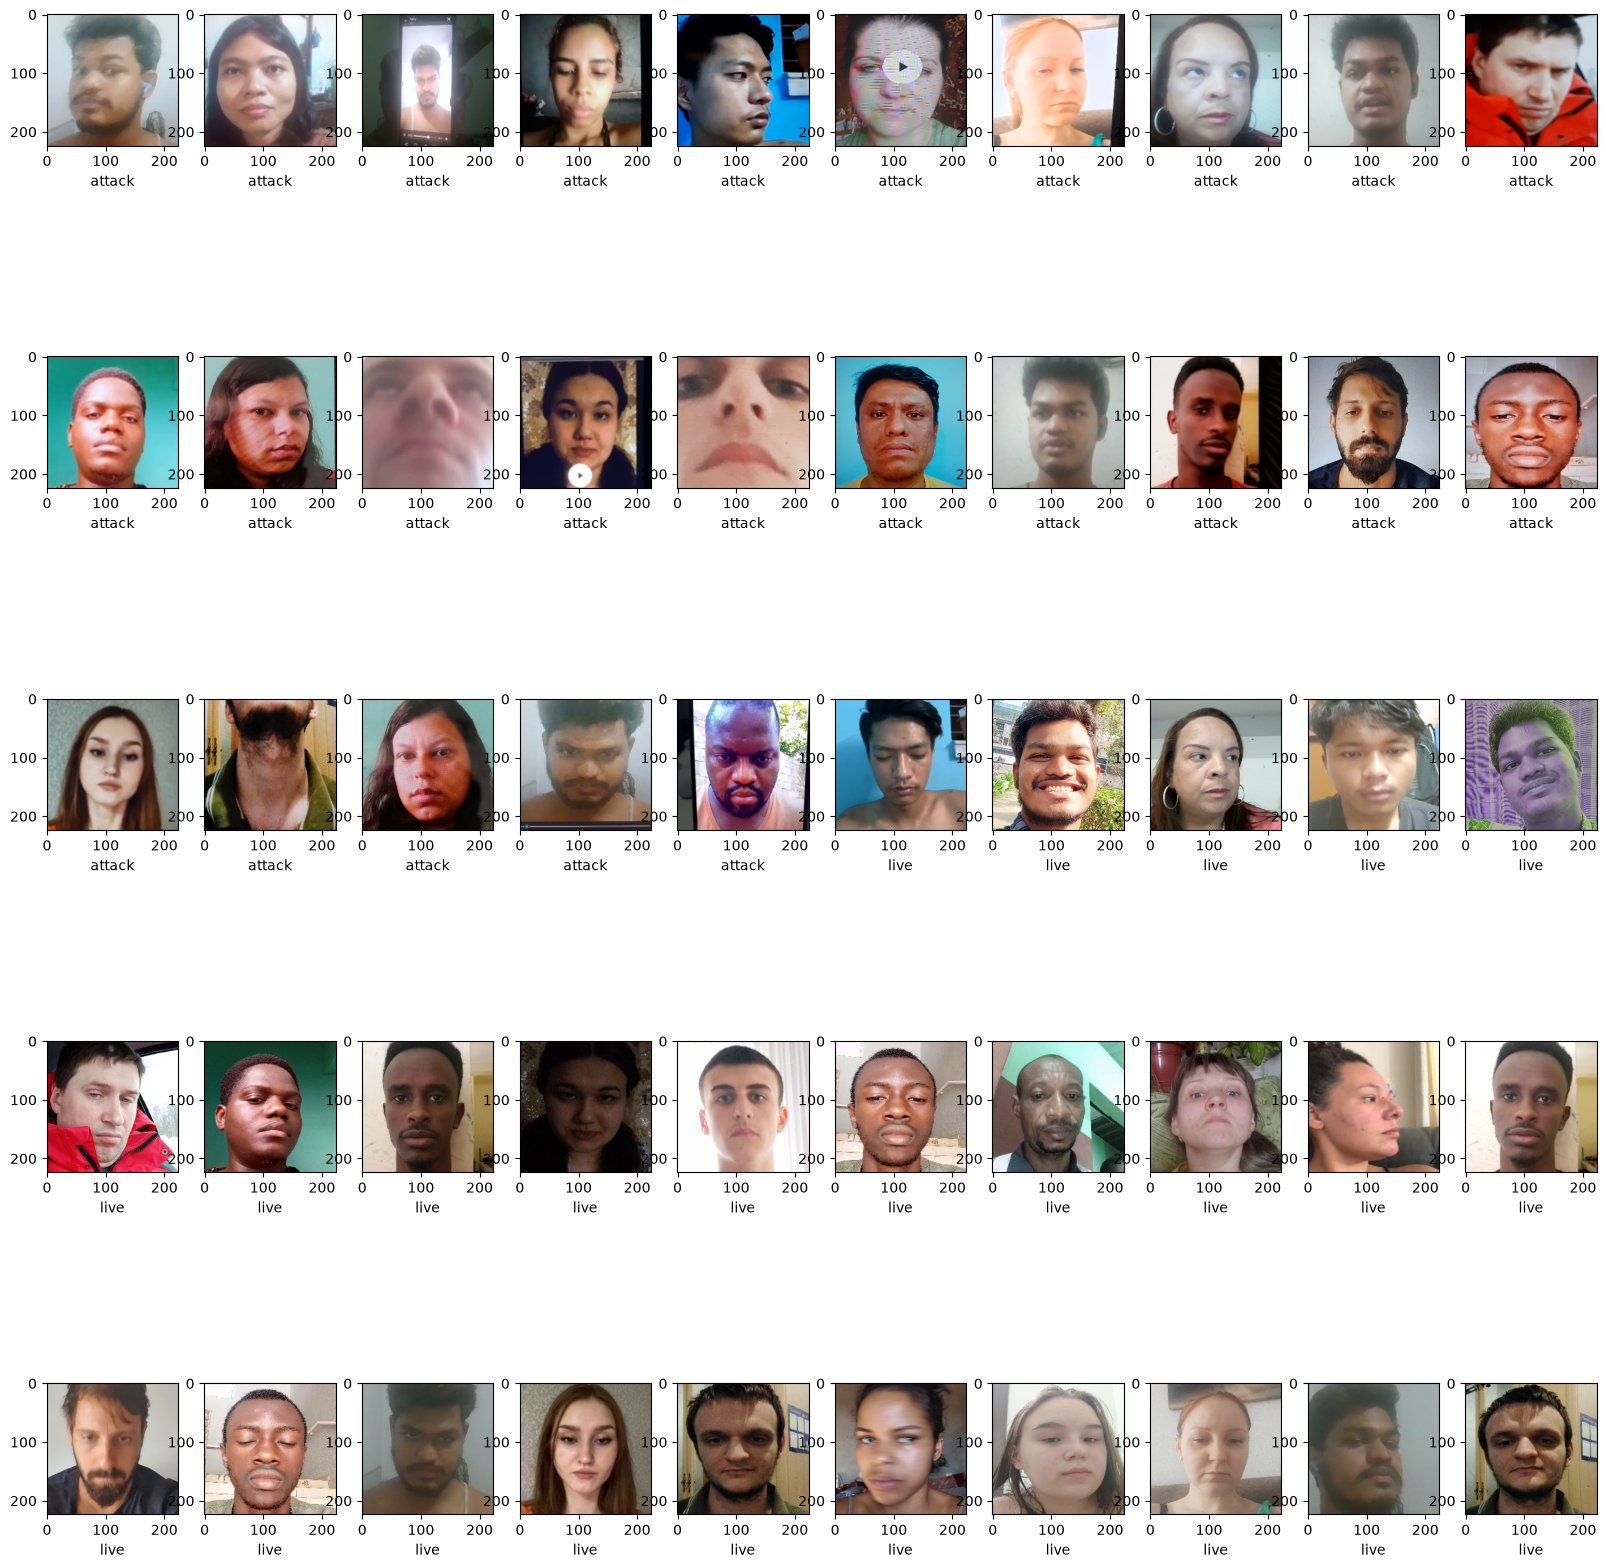

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Setup paths
base_dir = '/home/akash/my_project/new_processed_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
# test_dir = os.path.join(base_dir, 'test')

categories = ['attack', 'live']

def get_images(data_dir, number_of_samples):
    image_path = []
    for category in categories:
        path = os.path.join(data_dir, category)
        i = 1
        for img in os.listdir(path):
            if i > number_of_samples:
                break
            else:
                image_path.append(os.path.join(path, img))
                i += 1
    return image_path

def visualize_dataset(image_path, rows, cols):
    fig = plt.figure(figsize=(20, 20))
    for i in range(1, rows * cols + 1):
        fig.add_subplot(rows, cols, i)
        img_array = cv2.imread(image_path[i-1])
        fig.subplots_adjust(hspace=1)
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.xlabel(image_path[i-1].split('/')[-2])
    plt.show()

# 25 samples from each of the 2 categories = 50 images -> 5x10 grid fits perfectly
training_image_path = get_images(data_dir=train_dir, number_of_samples=25)
print(training_image_path)
print(len(training_image_path))

visualize_dataset(image_path=training_image_path, rows=5, cols=10)

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.03, fill_mode='nearest'),
    layers.RandomZoom(height_factor=(-0.08, 0.02), fill_mode='nearest'),
    layers.RandomBrightness(factor=0.08),
    layers.RandomContrast(factor=0.08)
])

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load a pre-trained, lightweight backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # Exclude the original ImageNet classifier head
    weights='imagenet'        # Leverage pre-trained features
)

# 2. Freeze the base model to prevent destroying learned features
base_model.trainable = False 

# 3. Assemble the full Spoofing Detection pipeline
model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),

    # data_augmentation,
    
    # Preprocessing: Maps pixels to [-1, 1] as required by MobileNetV2
    layers.Rescaling(scale=1/127.5, offset=-1),
    
    # Feature extraction base
    base_model,
    
    # Essential for small datasets: dramatically drops parameters to prevent overfitting
    layers.GlobalAveragePooling2D(),
    
    
    # Regularization layer to fight overfitting on 3.4k images
    layers.Dropout(0.4),
    
    # Final classification head (Binary output: Real vs Spoof)
    layers.Dense(1, activation='sigmoid')
])

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
# test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), # Low LR for stability
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, 224, 224, 3))

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
)

# print("\n--- Evaluating on Test Data ---")
# test_loss, test_accuracy = model.evaluate(test_ds)
# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_accuracy:.4f}")

model.save('/home/akash/my_project/models/temp_new_processed_dataset_trainable_false_rmsprop.keras')

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.5477 - loss: 0.7397 - val_accuracy: 0.6323 - val_loss: 0.6741
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6430 - loss: 0.6404 - val_accuracy: 0.7252 - val_loss: 0.6149
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6821 - loss: 0.5883 - val_accuracy: 0.7553 - val_loss: 0.5743
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7217 - loss: 0.5338 - val_accuracy: 0.7662 - val_loss: 0.5457
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7574 - loss: 0.5034 - val_accuracy: 0.7744 - val_loss: 0.5258
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7752 - loss: 0.4842 - val_accuracy: 0.7717 - val_loss: 0.5122
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7911 - loss: 0.4570 - val_accuracy: 0.7744 - val_loss: 0.5001
Epoch 8/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8053 - loss: 0.4377 - val_acc

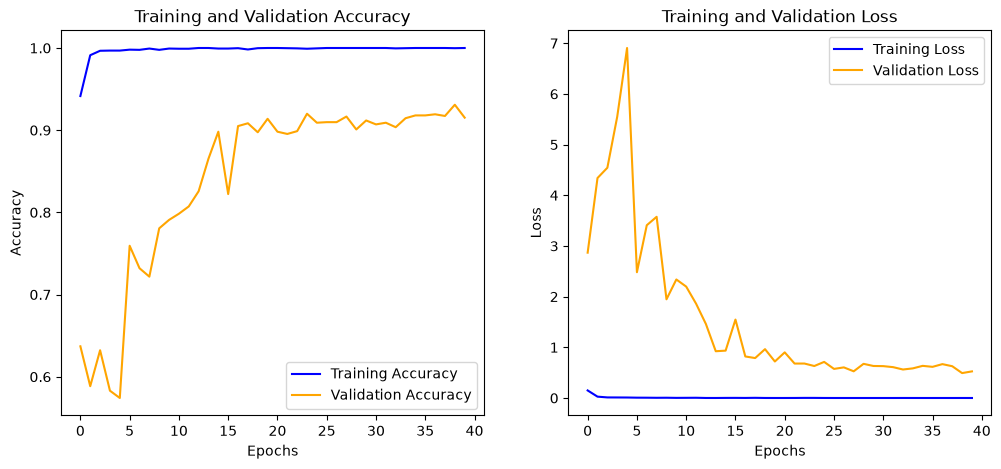

In [33]:
import matplotlib.pyplot as plt
# history = history_fine  # Use the fine-tuning history for plotting
# Extract metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot 2: Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()


In [17]:
# 1. Unfreeze the entire base model
base_model.trainable = True

# 2. Refreeze everything EXCEPT the last 20 layers
# MobileNetV2 has about 154 layers total
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. RECOMPILE with a much lower learning rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very gentle updates
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Check your summary again—you will see around 400,000+ trainable parameters now!
model.summary()

# 4. Train again for another 10-15 epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)
model.save('/home/akash/my_project/models/new_processed_dataset_trainable_true_Adam.keras')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,041,281 (3.97 MB)

 Non-trainable params: 1,217,984 (4.65 MB)

Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.9989 - loss: 0.0041 - val_accuracy: 0.8722 - val_loss: 0.5292
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 304ms/step - accuracy: 0.9998 - loss: 0.0025 - val_accuracy: 0.8722 - val_loss: 0.5342
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 656ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8701 - val_loss: 0.5325
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.8708 - val_loss: 0.5330
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9998 - loss: 0.0029 - val_accuracy: 0.8674 - val_loss: 0.5707
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.8660 - val_loss: 0.5579
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9998 - loss: 0.0030 - val_accuracy: 0.8640 - val_loss: 0.5498
Epoch 8/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9993 - loss: 0.0034 - val

W0000 00:00:1781852597.307688   35185 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0010

W0000 00:00:1781852601.398971   35300 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 1.0000 - loss: 8.0056e-04 - val_accuracy: 0.8660 - val_loss: 0.5998


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load a pre-trained, lightweight backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # Exclude the original ImageNet classifier head
    weights='imagenet'        # Leverage pre-trained features
)

# 2. Freeze the base model to prevent destroying learned features
base_model.trainable = True 

# 3. Assemble the full Spoofing Detection pipeline
model = models.Sequential([
    
    
    layers.Input(shape=(224, 224, 3)),


    # Preprocessing: Maps pixels to [-1, 1] as required by MobileNetV2
    layers.Rescaling(scale=1/127.5, offset=-1),
    
    # Feature extraction base
    base_model,
    
    # Essential for small datasets: dramatically drops parameters to prevent overfitting
    layers.GlobalAveragePooling2D(),
    
    
    # Regularization layer to fight overfitting on 3.4k images
    layers.Dropout(0.4),
    
    # Final classification head (Binary output: Real vs Spoof)
    layers.Dense(1, activation='sigmoid')
])

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
# test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), # Low LR for stability
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, 224, 224, 3))

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 2,225,153 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [4]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
)

model.save('/home/akash/my_project/models/new_processed_dataset_trainable_all-true_1_40epoch.keras')

Epoch 1/40


I0000 00:00:1781863708.824868   91458 service.cc:153] XLA service 0x74a544079180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781863708.824923   91458 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1781863709.250233   91458 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781863710.525830   91458 cuda_dnn.cc:461] Loaded cuDNN version 92302
E0000 00:00:1781863713.489182   91458 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781863716.182157   91458 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8670 - loss: 0.3001

E0000 00:00:1781863754.279496   91456 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 172ms/step - accuracy: 0.9317 - loss: 0.1690 - val_accuracy: 0.5632 - val_loss: 3.5607
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9957 - loss: 0.0135 - val_accuracy: 0.6042 - val_loss: 4.2031
Epoch 3/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9957 - loss: 0.0149 - val_accuracy: 0.7512 - val_loss: 2.0723
Epoch 4/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9973 - loss: 0.0074 - val_accuracy: 0.7642 - val_loss: 3.1055
Epoch 5/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9964 - loss: 0.0130 - val_accuracy: 0.8018 - val_loss: 2.1422
Epoch 6/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9980 - loss: 0.0057 - val_accuracy: 0.6972 - val_loss: 4.1123
Epoch 7/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.8284 - val_loss: 1.2901
Epoch 8/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9998 - loss: 0.0017 - val

In [ ]:
import tensorflow as tf
import numpy as np
import csv
import math
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ====== EDIT THESE ======
MODEL_PATH = "/home/akash/my_project/models/Final models/new_processed_dataset_trainable_true.keras"
BASE_DIR = "/home/akash/my_project/new_processed_dataset"
SPLITS = ["val"]          # only val and test — train is skipped on purpose
IMG_SIZE = (224, 224)              # must match your model's input size
IMAGES_PER_PAGE = 25                # 5x5 grid per page -> tune for bigger/smaller thumbnails
COLS = 5
# =========================

model = tf.keras.models.load_model(MODEL_PATH)


def evaluate_split(data_dir):
    eval_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=IMG_SIZE,
        batch_size=1,
        shuffle=False,   # keeps order so file_paths lines up with predictions
    )
    class_names = eval_ds.class_names
    file_paths = eval_ds.file_paths

    results = []
    for i, (image, label) in enumerate(eval_ds):
        pred = model.predict(image, verbose=0)

        # sigmoid (1 output neuron) -> threshold at 0.5; softmax (2 outputs) -> argmax
        if pred.shape[-1] == 1:
            pred_idx = int(pred[0][0] > 0.5)
            confidence = float(pred[0][0])
        else:
            pred_idx = int(np.argmax(pred[0]))
            confidence = float(np.max(pred[0]))

        true_idx = int(label.numpy()[0])

        results.append({
            "file": file_paths[i],
            "true_label": class_names[true_idx],
            "predicted_label": class_names[pred_idx],
            "confidence": round(confidence, 4),
            "correct": pred_idx == true_idx,
        })
    return results


def save_csv(results, output_csv):
    with open(output_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)


def save_all_predictions_pdf(results, images_per_page, cols, output_pdf):
    """
    Paginated grid showing EVERY image (correct and wrong), titled with
    its true label, predicted label, and confidence. Title is green for
    correct predictions and red for wrong ones, so you can flip through
    every page and instantly spot the mistakes.
    """
    rows = math.ceil(images_per_page / cols)
    total_pages = math.ceil(len(results) / images_per_page)

    with PdfPages(output_pdf) as pdf:
        for page in range(total_pages):
            start = page * images_per_page
            end = min(start + images_per_page, len(results))
            page_results = results[start:end]

            fig = plt.figure(figsize=(cols * 4, rows * 4))
            for i, r in enumerate(page_results, start=1):
                ax = fig.add_subplot(rows, cols, i)
                img = tf.keras.utils.load_img(r["file"], target_size=IMG_SIZE)
                ax.imshow(img)
                color = "green" if r["correct"] else "red"
                ax.set_title(
                    f"True: {r['true_label']}\nPred: {r['predicted_label']} ({r['confidence']:.2f})",
                    fontsize=9, color=color,
                )
                ax.set_xticks([])
                ax.set_yticks([])

            fig.suptitle(f"Page {page + 1}/{total_pages}  (images {start + 1}-{end} of {len(results)})")
            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    print(f"Saved {total_pages} pages ({len(results)} images) to {output_pdf}")


for split in SPLITS:
    print(f"\n=== Evaluating {split} ===")
    data_dir = f"{BASE_DIR}/{split}"
    results = evaluate_split(data_dir)

    correct = sum(r["correct"] for r in results)
    total = len(results)
    print(f"{split} accuracy: {correct}/{total} = {correct/total:.2%}")

    save_csv(results, f"{split}_predictions_results.csv")
    save_all_predictions_pdf(results, IMAGES_PER_PAGE, COLS, f"{split}_all_predictions2.pdf")


=== Evaluating val ===
Found 1463 files belonging to 2 classes.
val accuracy: 1272/1463 = 86.94%
Saved 59 pages (1463 images) to val_all_predictions2.pdf
